# correlation

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch

from utils import *
from modules import *

In [2]:
class RecurrentBaseline(nn.Module):
    """LSTM model for joint trajectory prediction."""

    def __init__(self, n_in, n_hid, n_out, n_atoms, n_layers, do_prob=0.):
        super(RecurrentBaseline, self).__init__()
        self.fc1_1 = nn.Linear(n_in, n_hid)
        self.fc1_2 = nn.Linear(n_hid, n_hid)
        self.rnn = nn.LSTM(n_atoms * n_hid, n_atoms * n_hid, n_layers)
        self.fc2_1 = nn.Linear(n_atoms * n_hid, n_atoms * n_hid)
        self.fc2_2 = nn.Linear(n_atoms * n_hid, n_atoms * n_out)

        self.bn = nn.BatchNorm1d(n_out)
        self.dropout_prob = do_prob

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                m.bias.data.fill_(0.1)
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def batch_norm(self, inputs):
        x = inputs.view(inputs.size(0) * inputs.size(1), -1)
        x = self.bn(x)
        return x.view(inputs.size(0), inputs.size(1), -1)

    def step(self, ins, hidden=None):
        # Input shape: [num_sims, n_atoms, n_in]
        x = F.relu(self.fc1_1(ins))
        x = F.dropout(x, self.dropout_prob, training=self.training)
        x = F.relu(self.fc1_2(x))
        x = x.view(ins.size(0), -1)
        # [num_sims, n_atoms*n_hid]

        x = x.unsqueeze(0)
        x, hidden = self.rnn(x, hidden)
        x = x[0, :, :]

        x = F.relu(self.fc2_1(x))
        x = self.fc2_2(x)
        # [num_sims, n_out*n_atoms]

        x = x.view(ins.size(0), ins.size(1), -1)
        # [num_sims, n_atoms, n_out]

        # Predict position/velocity difference
        x = x + ins

        return x, hidden

    def forward(self, inputs, prediction_steps, burn_in=False, burn_in_steps=1):

        # Input shape: [num_sims, num_things, num_timesteps, n_in]

        outputs = []
        hidden = None

        for step in range(0, inputs.size(2) - 1):

            if burn_in:
                if step <= burn_in_steps:
                    ins = inputs[:, :, step, :]
                else:
                    ins = outputs[step - 1]
            else:
                # Use ground truth trajectory input vs. last prediction
                if not step % prediction_steps:
                    ins = inputs[:, :, step, :]
                else:
                    ins = outputs[step - 1]

            output, hidden = self.step(ins, hidden)

            # Predict position/velocity difference
            outputs.append(output)

        outputs = torch.stack(outputs, dim=2)

        return outputs

In [3]:
# load_folder = 'logs/lstm/exp2025-04-29T16:03:21.860888/'
load_folder = 'logs/lstm/exp2025-05-01T16:19:11.985984/'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(os.path.join(load_folder, 'metadata.pkl'), 'rb') as f:
    meta = pickle.load(f)
args = meta['args']

model = RecurrentBaseline(args.dims, args.hidden, args.dims,
                          args.num_atoms, args.num_layers, args.dropout)

model.load_state_dict(torch.load(os.path.join(load_folder, 'model.pt'), map_location=device))

<All keys matched successfully>

In [4]:
# Linear indices of an upper triangular mx, used for loss calculation
triu_indices = get_triu_offdiag_indices(args.num_atoms)

In [5]:
train_loader, valid_loader, test_loader, loc_max, loc_min, vel_max, vel_min = \
    load_data(args.batch_size, subfolder='charged', suffix=args.suffix)

In [11]:
N = 50000
Ca = np.zeros((N,20))
Ra = np.zeros((N,20))

model.eval()

k = 0
for batch_idx, (data, relations) in enumerate(train_loader):
        with torch.no_grad():
            data, relations = Variable(data), Variable(relations)

        # output = model(data, 1)
        # output = output.detach().numpy()

        n = data.shape[0]

        # loop through the batch
        for i in range(n):
            C = np.corrcoef(data[i].reshape(5,-1))
            # C = np.corrcoef(output[i].reshape(5,-1))
            C = C[~np.eye(C.shape[0], dtype=bool)].flatten()
            Ca[k,:] = C
            Ra[k,:] = relations[i]
            k += 1

            if k % 5000 == 0: print(k)

/local/scr/stmorse/TMPDIR/ipykernel_1198106/2965683227.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Ra[k,:] = relations[i]


5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


In [15]:
for theta in np.arange(0.7, 1.01, .01):
    # theta = 0.99
    Za = np.ones(Ca.shape)
    Za[np.abs(Ca) < theta] = 0
    # Za[Ca < theta] = 0
    acc = np.mean(Za == Ra)
    print(f'Accuracy ({theta:.2f}): {acc:.4f}')

Accuracy (0.70): 0.5093
Accuracy (0.71): 0.5098
Accuracy (0.72): 0.5100
Accuracy (0.73): 0.5103
Accuracy (0.74): 0.5104
Accuracy (0.75): 0.5106
Accuracy (0.76): 0.5110
Accuracy (0.77): 0.5111
Accuracy (0.78): 0.5110
Accuracy (0.79): 0.5112
Accuracy (0.80): 0.5114
Accuracy (0.81): 0.5115
Accuracy (0.82): 0.5115
Accuracy (0.83): 0.5113
Accuracy (0.84): 0.5110
Accuracy (0.85): 0.5106
Accuracy (0.86): 0.5101
Accuracy (0.87): 0.5095
Accuracy (0.88): 0.5088
Accuracy (0.89): 0.5082
Accuracy (0.90): 0.5073
Accuracy (0.91): 0.5063
Accuracy (0.92): 0.5055
Accuracy (0.93): 0.5044
Accuracy (0.94): 0.5035
Accuracy (0.95): 0.5025
Accuracy (0.96): 0.5016
Accuracy (0.97): 0.5010
Accuracy (0.98): 0.5005
Accuracy (0.99): 0.5003
Accuracy (1.00): 0.5002
Accuracy (1.01): 0.5002


# error plots

In [47]:
import matplotlib.pyplot as plt
import numpy as np

In [16]:
lstm_errs = [ 0.000004837666 , 0.000018982251 , 0.000041831674 , 0.000073274736 , 0.000114111877 , 0.000166056896 , 0.000231471073 , 0.000313046650 , 0.000413731817 , 0.000536778185 , 0.000685840962 , 0.000864981266 , 0.001078536967 , 0.001331079286 , 0.001627469785 , 0.001972920494 , 0.002372931922 , 0.002836080734 , 0.003362202551 , 0.003956606612 ]
base_errs = [ 0.000078298181 , 0.000312591990 , 0.000701709709 , 0.001244124258 , 0.001937958645 , 0.002780992072 , 0.003770666430 , 0.004904094152 , 0.006178058218 , 0.007589018904 , 0.009133123793 , 0.010806215927 , 0.012603825890 , 0.014521185309 , 0.016553252935 , 0.018694678321 , 0.020939871669 , 0.023285211995 , 0.025722427294 , 0.028244879097 ]
vgae_errs = [ 0.000000199111 , 0.000000803070 , 0.000001820112 , 0.000003255687 , 0.000005112663 , 0.000007390863 , 0.000010087545 , 0.000013198582 , 0.000016717222 , 0.000020634550 , 0.000024940813 , 0.000029621675 , 0.000034666533 , 0.000040063649 , 0.000045804132 , 0.000051877432 , 0.000058271682 , 0.000067258661 , 0.000076732897 , 0.000086386412 ]

c_lstm_errs = [ 0.001865467289 , 0.002689142013 , 0.003167316783 , 0.003644205630 , 0.004120414611 , 0.004553426988 , 0.005002149846 , 0.005549508147 , 0.006079371087 , 0.006741211284 , 0.007425863761 , 0.008301621303 , 0.008938763291 , 0.009903488681 , 0.010948906653 , 0.012073760852 , 0.013343264349 , 0.014495801181 , 0.015898145735 , 0.017427524552 ]
c_base_errs =  [ 0.005020947661 , 0.006921110209 , 0.008373143151 , 0.010038243607 , 0.011863989756 , 0.013644999824 , 0.015720203519 , 0.017886688933 , 0.020188868046 , 0.022630790249 , 0.025186410174 , 0.028130102903 , 0.030713479966 , 0.033665396273 , 0.036944154650 , 0.040208179504 , 0.043668296188 , 0.046911168844 , 0.050492890179 , 0.054206419736 ]
c_vgae_errs =  [ 0.001446609967 , 0.001679944806 , 0.001943543204 , 0.002218615497 , 0.002553570783 , 0.002830915153 , 0.003097338136 , 0.003391012782 , 0.003676040564 , 0.003996800166 , 0.004434129689 , 0.004905541427 , 0.005098578986 , 0.005634450354 , 0.006166006904 , 0.006720594130 , 0.007317902055 , 0.007760426030 , 0.008452832699 , 0.009067620151 ]


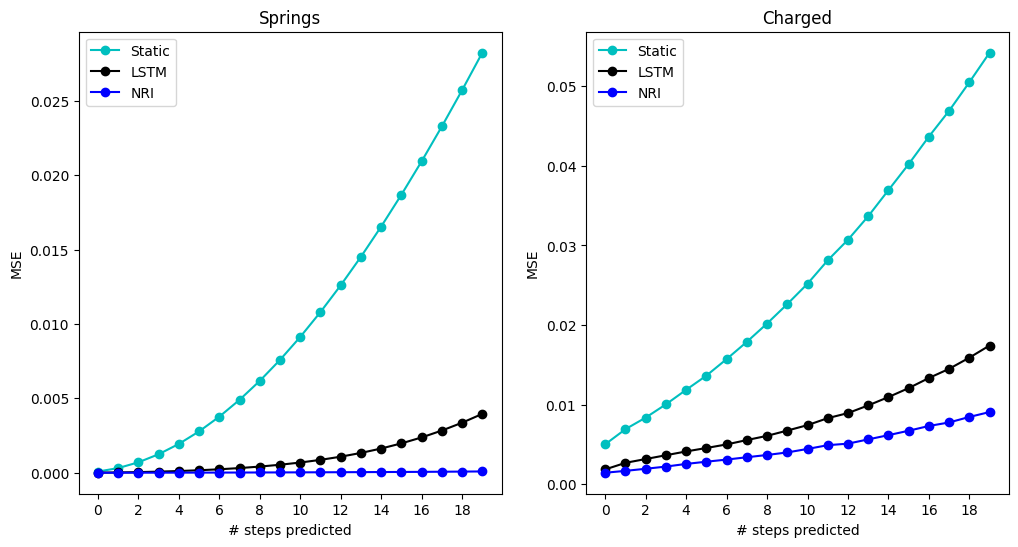

In [17]:
fig, axs = plt.subplots(1,2, figsize=(12,6))

colors = ['c', 'k', 'b']
labels = ['Static', 'LSTM', 'NRI']

ax = axs[0]
for i, errs in enumerate([base_errs, lstm_errs, vgae_errs]):
    n = len(errs)
    ax.plot(range(n), errs, linestyle='-', marker='o', color=colors[i], label=labels[i])

ax.set_xticks(range(0, n, 2))
ax.set_xticklabels(range(0, n, 2))
ax.set_xlabel('# steps predicted')
ax.set_ylabel('MSE')
ax.set_title('Springs')
ax.legend()

ax = axs[1]
for i, errs in enumerate([c_base_errs, c_lstm_errs, c_vgae_errs]):
    n = len(errs)
    ax.plot(range(n), errs, linestyle='-', marker='o', color=colors[i], label=labels[i])

ax.set_xticks(range(0, n, 2))
ax.set_xticklabels(range(0, n, 2))
ax.set_xlabel('# steps predicted')
ax.set_ylabel('MSE')
ax.set_title('Charged')
ax.legend()

plt.show()

# Demonstrate model on springs

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch

from utils import *
from modules import *

In [2]:
load_folder = 'logs/gae/exp2025-04-29T15:54:52.341671/'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(os.path.join(load_folder, 'metadata.pkl'), 'rb') as f:
    meta = pickle.load(f)
args = meta['args']

encoder = MLPEncoder(
    args.timesteps * args.dims, 
    args.encoder_hidden,
    args.edge_types,
    args.encoder_dropout, args.factor
)

decoder = MLPDecoder(
    n_in_node=args.dims,
    edge_types=args.edge_types,
    msg_hid=args.decoder_hidden,
    msg_out=args.decoder_hidden,
    n_hid=args.decoder_hidden,
    do_prob=args.decoder_dropout,
    skip_first=args.skip_first
)

encoder.load_state_dict(torch.load(os.path.join(load_folder, 'encoder.pt'), map_location=device))
decoder.load_state_dict(torch.load(os.path.join(load_folder, 'decoder.pt'), map_location=device))

Using factor graph MLP encoder.
Using learned interaction net decoder.


<All keys matched successfully>

In [3]:
train_loader, valid_loader, test_loader, loc_max, loc_min, vel_max, vel_min = \
    load_data(args.batch_size, subfolder='springsfull', suffix=args.suffix)

In [4]:
# Generate off-diagonal interaction graph
off_diag = np.ones([args.num_atoms, args.num_atoms]) - np.eye(args.num_atoms)

rel_rec = np.array(encode_onehot(np.where(off_diag)[0]), dtype=np.float32)
rel_send = np.array(encode_onehot(np.where(off_diag)[1]), dtype=np.float32)
rel_rec = torch.FloatTensor(rel_rec)
rel_send = torch.FloatTensor(rel_send)

In [20]:
encoder.eval()
decoder.eval()

for batch_idx, (data, relations) in enumerate(valid_loader):
        with torch.no_grad():
            data, relations = Variable(data), Variable(relations)

        # only for test
        # data_encoder = data[:, :, :args.timesteps, :].contiguous()
        # data_decoder = data[:, :, -args.timesteps:, :].contiguous()

        logits = encoder(data, rel_rec, rel_send)
        edges = gumbel_softmax(logits, tau=args.temp, hard=False)
        prob = my_softmax(logits, -1)

        # validation output uses teacher forcing
        output = decoder(data, edges, rel_rec, rel_send, 1)

        target = data[:, :, 1:, :]

        break

In [23]:
# data: (batch, atoms, time, dim)
# edges/prob: (batch, edge, dim)
data.shape, relations.shape, edges.shape, prob.shape, output.shape

(torch.Size([128, 5, 49, 4]),
 torch.Size([128, 20]),
 torch.Size([128, 20, 2]),
 torch.Size([128, 20, 2]),
 torch.Size([128, 5, 48, 4]))

In [25]:
encoder.eval()
decoder.eval()

for batch_idx, (data, relations) in enumerate(test_loader):
    with torch.no_grad():
        data, relations = Variable(data), Variable(relations)

    data_encoder = data[:, :, :args.timesteps, :].contiguous()
    data_decoder = data[:, :, -args.timesteps:, :].contiguous()

    logits = encoder(data_encoder, rel_rec, rel_send)
    edges = gumbel_softmax(logits, tau=args.temp, hard=True)

    prob = my_softmax(logits, -1)

    output_full = decoder(data_decoder, edges, rel_rec, rel_send, 1)

    target = data_decoder[:, :, 1:, :]
    
    data_plot = data[:, :, args.timesteps:args.timesteps + 21,
                :].contiguous()
    output = decoder(data_plot, edges, rel_rec, rel_send, 20)
    target = data_plot[:, :, 1:, :]

    break

In [ ]:
# for test, data is 99 long (49 + 50)
# encoder gets first 49, predicts edges
# decoder gets last 49, predicts outputs
# data_plot is first 20 after the 49 from encoder input
data.shape, relations.shape, edges.shape, prob.shape, output_full.shape, output.shape

(torch.Size([128, 5, 99, 4]),
 torch.Size([128, 20]),
 torch.Size([128, 20, 2]),
 torch.Size([128, 20, 2]),
 torch.Size([128, 5, 48, 4]),
 torch.Size([128, 5, 20, 4]))

In [7]:
edges[100, :, :]

tensor([[1.0000e+00, 1.2256e-15],
        [1.0000e+00, 3.1500e-12],
        [8.8713e-02, 9.1129e-01],
        [1.0000e+00, 1.1275e-18],
        [1.0000e+00, 6.2520e-21],
        [9.2290e-30, 1.0000e+00],
        [1.0000e+00, 1.5726e-33],
        [0.0000e+00, 1.0000e+00],
        [1.0000e+00, 9.7760e-14],
        [9.0898e-26, 1.0000e+00],
        [1.0000e+00, 5.8422e-14],
        [1.0000e+00, 0.0000e+00],
        [6.5319e-07, 1.0000e+00],
        [1.0000e+00, 1.7886e-33],
        [1.0000e+00, 2.4050e-13],
        [0.0000e+00, 1.0000e+00],
        [1.0000e+00, 1.7174e-26],
        [3.5503e-41, 1.0000e+00],
        [1.0000e+00, 4.3382e-40],
        [5.5071e-43, 1.0000e+00]], grad_fn=<SliceBackward0>)

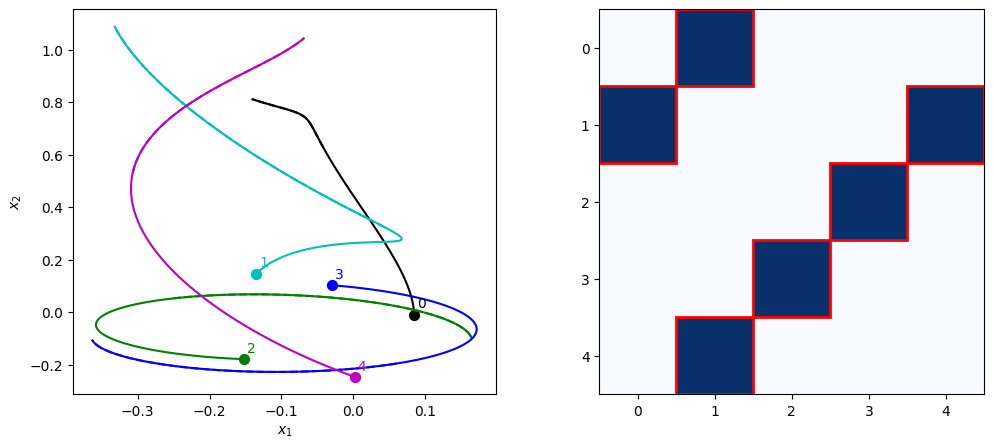

In [30]:
# sample within batch
s = 3

prob_a = prob.detach().numpy()
# output_a = output.detach().numpy()
output_a = output_full.detach().numpy()

# total time steps
max_t = data.shape[2]

# color scheme for each object ("atom")
colors = ['k', 'c', 'g', 'b', 'm']

fig, axs = plt.subplots(1,2, figsize=(12,5))

# ----
# Draw trajectories
# ----

a, b = 0, 99
c, d = 0, 49

ax = axs[0]
for atom, color in enumerate(colors):
    # plot trajectory
    ax.plot(data[s, atom, a:b, 0], 
            data[s, atom, a:b, 1], 
            color=color, linestyle='-')

    # plot dot marker at beginning of trajectory
    ax.scatter(data[s, atom, a, 0], data[s, atom, a, 1],
               c=color, s=50, marker='o', )
    
    # plot predicted trajectory
    ax.plot(output_a[s, atom, c:d, 0], 
            output_a[s, atom, c:d, 1], 
            color=color, linestyle='--')

    # annotate the dot marker
    ax.annotate(f'{atom}', 
                (data[s, atom, a, 0], data[s, atom, a, 1]), 
                textcoords="offset points", 
                xytext=(5, 5), 
                ha='center', color=color)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

# ----
# Draw relations
# ----

ax = axs[1]

# prob is the off-diagonal-indices this is a hack to convert
# 0 -> (0,1), 1 -> (0,2), ... 15 -> (3,4)
# pdct[index in relations / prob]: (i,j)
pdct = {}
k = 0
for i in range(5):
    for j in range(5):
        if i == j: continue
        pdct[k] = (i,j)
        k += 1

# Convert prob_a to a square matrix with diagonal set to zero
A = np.zeros((args.num_atoms, args.num_atoms))
B = np.zeros((args.num_atoms, args.num_atoms))
for k in range(relations.shape[1]):
    i, j = pdct[k]
    A[i, j] = prob_a[s, k, 1]
    B[i, j] = relations[s, k]

ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
for i in range(args.num_atoms):
    for j in range(args.num_atoms):
        if B[i, j] == 1:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, edgecolor='red', fill=False, lw=2))

plt.show()

In [ ]:
# draw atoms in a circle
# xy holds xy coordinates of each atom
# xy = []
# for i in range(5):
#     deg = (2 * np.pi / 5) * i
#     xy.append([np.cos(deg), np.sin(deg)])
#     ax.scatter([np.cos(deg)], [np.sin(deg)],
#                s=100, c=colors[i], zorder=100)
# xy = np.array(xy)

# # prob is the off-diagonal-indices this is a hack to convert
# # 0 -> (0,1), 1 -> (0,2), ... 15 -> (3,4)
# # pdct[index in relations / prob]: (i,j)
# pdct = {}
# k = 0
# for i in range(5):
#     for j in range(5):
#         if i == j: continue
#         pdct[k] = (i,j)
#         k += 1

# # draw lines
# for k in range(relations.shape[1]):
#     e = pdct[k]
#     u, v = xy[e,0], xy[e,1]
    
#     # plot ground truth
#     if relations[s,k] == 1:
#         ax.plot(u, v, 1, color='k')

#     # plot learned
#     ax.plot(u, v, color='k', linewidth=prob_a[s,k,1]*4, alpha=0.3)

# ax.set_xlim([-1.25, 1.25])
# ax.set_ylim([-1.25, 1.25])
# ax.set_axis_off()

In [39]:
np.where((prob < 0.8) & (prob > 0.1))[0]

array([  2,   4,   4,   6,   6,  30,  30,  35,  35,  76, 102, 102, 112,
       112, 112])

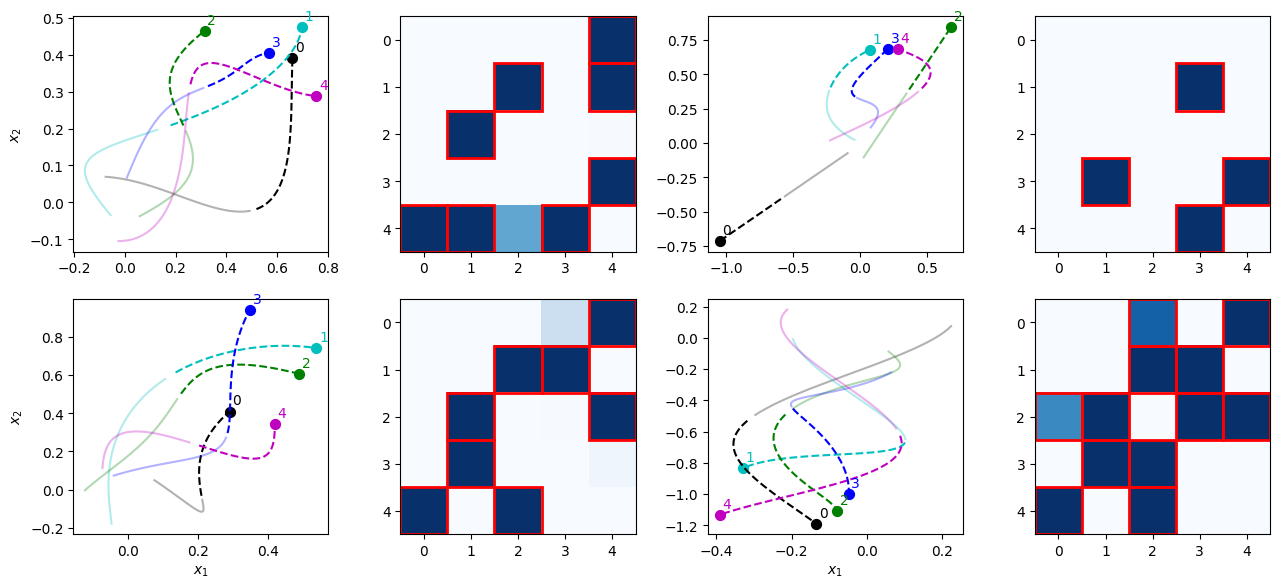

In [46]:
# sample within batch
ss = [4, 21, 102, 112,]

prob_a = prob.detach().numpy()
# output_a = output.detach().numpy()
output_a = output_full.detach().numpy()

# total time steps
max_t = data.shape[2]

# color scheme for each object ("atom")
colors = ['k', 'c', 'g', 'b', 'm']

fig, axs = plt.subplots(2,4, figsize=(13,6))

# ----
# Draw trajectories
# ----

a,b = 0, 49
c,d = 0, 48

m = 0
for row in range(2):
    for col in [0, 2]:
        ax = axs[row,col]
        s = ss[m]
        m += 1

        for atom, color in enumerate(colors):
            # plot trajectory
            ax.plot(data[s, atom, a:b, 0], 
                    data[s, atom, a:b, 1], 
                    color=color, linestyle='-', alpha=0.3)

            # plot dot marker at end of trajectory
            ax.scatter(output_a[s, atom, d-1, 0], output_a[s, atom, d-1, 1],
                    c=color, s=50, marker='o', )
            
            # plot predicted trajectory
            ax.plot(output_a[s, atom, c:d, 0], 
                    output_a[s, atom, c:d, 1], 
                    color=color, linestyle='--')

            # annotate the dot marker
            ax.annotate(f'{atom}', 
                        (output_a[s, atom, d-1, 0], output_a[s, atom, d-1, 1]), 
                        textcoords="offset points", 
                        xytext=(5, 5), 
                        ha='center', color=color)

        if row == 1:
            ax.set_xlabel('$x_1$')
        
        if col == 0:
            ax.set_ylabel('$x_2$')

# ----
# Draw relations
# ----

m = 0
for row in range(2):
    for col in [1, 3]:

        ax = axs[row,col]
        s = ss[m]
        m += 1

        # prob is the off-diagonal-indices this is a hack to convert
        # 0 -> (0,1), 1 -> (0,2), ... 15 -> (3,4)
        # pdct[index in relations / prob]: (i,j)
        pdct = {}
        k = 0
        for i in range(5):
            for j in range(5):
                if i == j: continue
                pdct[k] = (i,j)
                k += 1

        # Convert prob_a to a square matrix with diagonal set to zero
        A = np.zeros((args.num_atoms, args.num_atoms))
        B = np.zeros((args.num_atoms, args.num_atoms))
        for k in range(relations.shape[1]):
            i, j = pdct[k]
            A[i, j] = prob_a[s, k, 1]
            B[i, j] = relations[s, k]

        ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
        for i in range(args.num_atoms):
            for j in range(args.num_atoms):
                if B[i, j] == 1:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, edgecolor='red', fill=False, lw=2))

plt.tight_layout()
plt.show()